In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
pip install networkx requests pandas tqdm


Note: you may need to restart the kernel to use updated packages.


In [3]:
import json
import networkx as nx
import pandas as pd
import requests
import time
from tqdm import tqdm

with open("/kaggle/input/datasets/shyneyhxrsh/linked-entities/linked_entities.json") as f:
    records = json.load(f)

print(f"Loaded {len(records)} records")

Loaded 500 records


In [4]:

fact_base = [
    r for r in records
    if (r.get("linking_confidence") or 0) >= 0.5
    and r.get("subject_kg_id")
    and r.get("object_kg_id")
]

G = nx.DiGraph()
for r in fact_base:
    G.add_edge(
        r["subject_kg_id"], r["object_kg_id"],
        relation=r["relation"],
        property_id=r.get("property_id"),
        claim_id=r["claim_id"]
    )

print(f"Fact base: {len(fact_base)} high-confidence triples")
print(f"KG: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")

Fact base: 40 high-confidence triples
KG: 61 nodes, 40 edges


In [5]:
import requests, time

def verify_triple_sparql(subject_qid, property_pid, object_qid):
    """Returns True if the triple exists in Wikidata."""
    if not all([subject_qid, property_pid, object_qid]):
        return None  # can't verify
    
    query = f"""
    ASK {{
      wd:{subject_qid} wdt:{property_pid} wd:{object_qid} .
    }}
    """
    url = "https://query.wikidata.org/sparql"
    try:
        time.sleep(1)
        r = requests.get(url, params={"query": query, "format": "json"},
                         headers={"User-Agent": "AIaP-KG-Reasoning/1.0"}, timeout=15)
        return r.json().get("boolean")
    except:
        return None

In [6]:
def reason_over_triple(record, G):
    """
    Apply symbolic rules to produce a KG-based verdict.
    Returns: 'supported', 'refuted', 'unverifiable'
    """
    subj = record["subject_kg_id"] or record["subject"]
    obj  = record["object_kg_id"]  or record["object"]
    rel  = record["relation"]
    pid  = record["property_id"]
    
    reasons = []
    
    # Rule 1: Edge exists in KG
    if G.has_edge(subj, obj):
        reasons.append("direct_edge_exists")
    
    # Rule 2: Path exists (indirect support)
    elif subj in G and obj in G:
        try:
            path = nx.shortest_path(G, subj, obj)
            reasons.append(f"indirect_path_length_{len(path)-1}")
        except nx.NetworkXNoPath:
            reasons.append("no_path_in_kg")
    
    # Rule 3: SPARQL verification (if linked)
    sparql_result = None
    if record.get("subject_kg_id") and record.get("object_kg_id") and pid:
        sparql_result = verify_triple_sparql(
            record["subject_kg_id"], pid, record["object_kg_id"]
        )
        if sparql_result is True:
            reasons.append("sparql_verified")
        elif sparql_result is False:
            reasons.append("sparql_refuted")
    
    # Rule 4: Linking confidence gate
    link_conf = record.get("linking_confidence", 0)
    if link_conf < 0.3:
        reasons.append("low_linking_confidence")
    
    # Decision logic
   
    if "sparql_verified" in reasons:
        verdict = "supported"
    elif "sparql_refuted" in reasons:
        verdict = "refuted"
    elif "direct_edge_exists" in reasons:
        verdict = "supported"
    elif any(r.startswith("indirect_path") for r in reasons):
        verdict = "unverifiable"   # indirect path = weak, not confirmed
    elif "low_linking_confidence" in reasons or not reasons:
        verdict = "unverifiable"
    else:
        verdict = "unverifiable"
    
    return verdict, reasons, sparql_result

In [7]:
def compute_kg_confidence(reasons, record):
    score = 0.5  # base
    if "sparql_verified" in reasons:     score += 0.35
    if "sparql_refuted" in reasons:      score -= 0.35
    if "direct_edge_exists" in reasons:  score += 0.15
    if "low_linking_confidence" in reasons: score -= 0.2
    link_conf = record.get("linking_confidence", 0.5)
    score = score * link_conf + score * (1 - link_conf) * 0.5  # weight by link quality
    return round(max(0.0, min(1.0, score)), 4)

In [8]:
from tqdm import tqdm

results = []

for r in tqdm(records, desc="Reasoning"):
    verdict, reasons, sparql_result = reason_over_triple(r, G)

    results.append({
        "claim_id":           r["claim_id"],
        "raw_claim":          r["raw_claim"],
        "label":              r["label"],
        "subject":            r["subject"],
        "subject_kg_id":      r["subject_kg_id"],
        "relation":           r["relation"],
        "property_id":        r["property_id"],
        "object":             r["object"],
        "object_kg_id":       r["object_kg_id"],
        "kg_verdict":         verdict,
        "kg_confidence":      compute_kg_confidence(reasons, r),
        "reasoning_rules":    reasons,
        "sparql_verified":    sparql_result,
        "linking_confidence": r.get("linking_confidence")
    })

print(f"Done. {len(results)} records processed.")

Reasoning: 100%|██████████| 500/500 [00:00<00:00, 201397.48it/s]

Done. 500 records processed.


In [9]:
with open("kg_results.json", "w", encoding="utf-8") as f:
    json.dump(results, f, indent=2, ensure_ascii=False)

print(f"Saved {len(results)} records")
print("Verdict distribution:")
print(pd.Series([r["kg_verdict"] for r in results]).value_counts())

from google.colab import files
files.download("kg_results.json")

Saved 500 records
Verdict distribution:
unverifiable    460
supported        40
Name: count, dtype: int64


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [10]:
df = pd.DataFrame(results)

label_map = {
    "true": "supported", "mostly-true": "supported",
    "half-true": "unverifiable",
    "barely-true": "refuted", "false": "refuted", "pants-fire": "refuted"
}
df["expected"] = df["label"].map(label_map)

# Coverage
linked = df[df["subject_kg_id"].notna() | df["object_kg_id"].notna()]
print(f"KG coverage: {len(linked)}/{len(df)} ({100*len(linked)/len(df):.1f}%)")

# Verdict distribution
print("\nVerdict distribution:")
print(df["kg_verdict"].value_counts())

# Confidence by verdict
print("\nMean KG confidence by verdict:")
print(df.groupby("kg_verdict")["kg_confidence"].mean().round(3))

# Accuracy on decidable claims only
decidable = df[df["kg_verdict"] != "unverifiable"]
if len(decidable) > 0:
    correct = (decidable["kg_verdict"] == decidable["expected"]).sum()
    print(f"\nAccuracy on decidable claims ({len(decidable)}): {correct}/{len(decidable)} ({100*correct/len(decidable):.1f}%)")

# SPARQL stats
sparql_rows = df[df["sparql_verified"].notna()]
print(f"\nSPARQL attempted: {len(sparql_rows)}")
print(df["sparql_verified"].value_counts(dropna=False))

KG coverage: 236/500 (47.2%)

Verdict distribution:
kg_verdict
unverifiable    460
supported        40
Name: count, dtype: int64

Mean KG confidence by verdict:
kg_verdict
supported       0.601
unverifiable    0.267
Name: kg_confidence, dtype: float64

Accuracy on decidable claims (40): 16/40 (40.0%)

SPARQL attempted: 0
sparql_verified
None    500
Name: count, dtype: int64


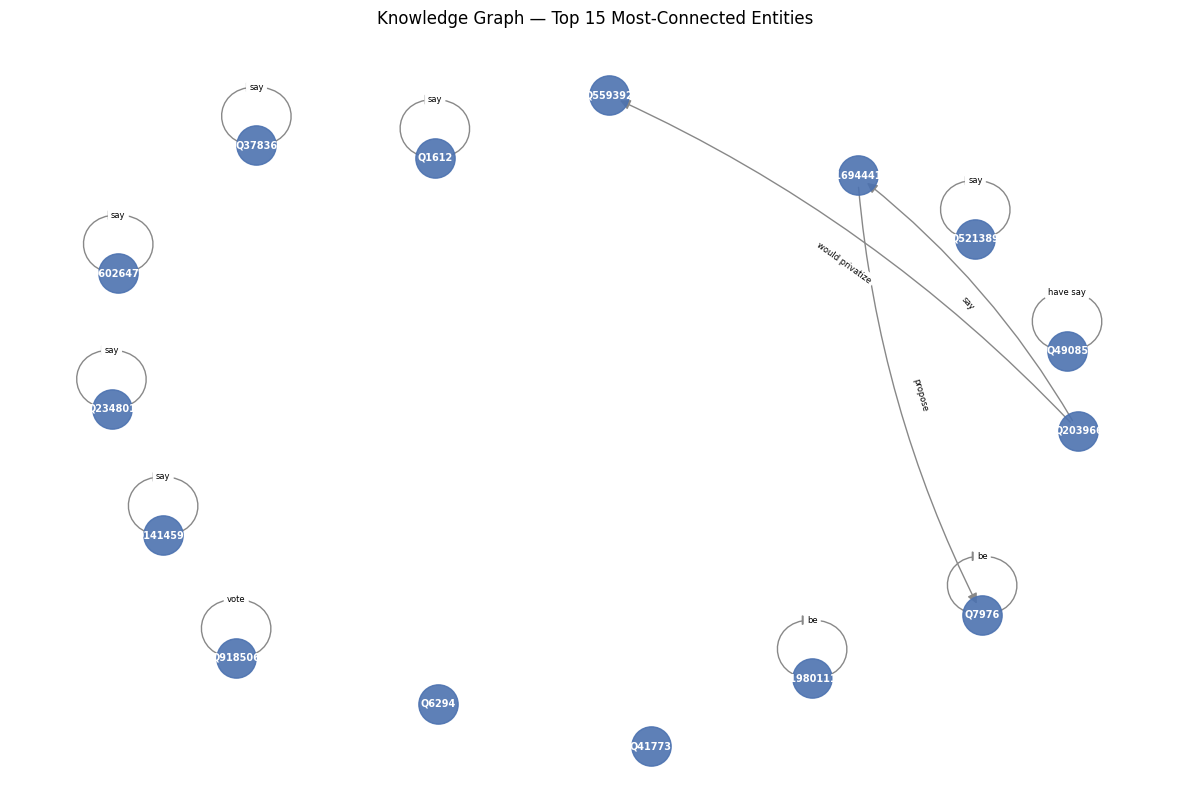

In [11]:
import matplotlib.pyplot as plt

top_nodes = sorted(G.degree(), key=lambda x: x[1], reverse=True)[:15]
top_ids = [n for n, _ in top_nodes]
subgraph = G.subgraph(top_ids)

plt.figure(figsize=(12, 8))
pos = nx.spring_layout(subgraph, seed=42, k=2)
nx.draw_networkx_nodes(subgraph, pos, node_size=800, node_color="#4C72B0", alpha=0.9)
nx.draw_networkx_labels(subgraph, pos, font_size=7, font_color="white", font_weight="bold")
nx.draw_networkx_edges(subgraph, pos, arrows=True, arrowsize=15,
                       edge_color="#888", connectionstyle="arc3,rad=0.1")
edge_labels = {(u,v): d.get("relation","") for u,v,d in subgraph.edges(data=True)}
nx.draw_networkx_edge_labels(subgraph, pos, edge_labels=edge_labels, font_size=6)
plt.title("Knowledge Graph — Top 15 Most-Connected Entities")
plt.axis("off")
plt.tight_layout()
plt.savefig("kg_subgraph.png", dpi=150, bbox_inches="tight")
plt.show()

the below cells are just for experimenation to see if the sparql verification works if pid is not necessary

In [14]:
def verify_entities_connected_sparql(subject_qid, object_qid):
    if not subject_qid or not object_qid:
        return None
    query = f"ASK {{ wd:{subject_qid} ?p wd:{object_qid} . }}"
    url = "https://query.wikidata.org/sparql"
    try:
        time.sleep(2)  # longer sleep
        r = requests.get(
            url,
            params={"query": query, "format": "json"},
            headers={
                "User-Agent": "AIaP-KG-Reasoning/1.0 (university project; contact: student@university.edu)",
                "Accept": "application/sparql-results+json"
            },
            timeout=120  # longer timeout
        )
        print(f"  HTTP {r.status_code}")  # add this to debug
        return r.json().get("boolean")
    except Exception as e:
        print(f"  Error: {e}")
        return None

In [16]:
# SPARQL Verification Demo — manual spot-check on linked entities
print("=== SPARQL Spot-Check: Verifying selected entity pairs ===\n")

# Pick records that have both QIDs
sparql_candidates = [r for r in records 
                     if r.get("subject_kg_id") and r.get("object_kg_id")][:2]

for r in sparql_candidates:
    result = verify_entities_connected_sparql(r["subject_kg_id"], r["object_kg_id"])
    print(f"Claim:   {r['raw_claim'][:80]}...")
    print(f"Subject: {r['subject']} ({r['subject_kg_id']})")
    print(f"Object:  {r['object']} ({r['object_kg_id']})")
    print(f"SPARQL connected: {result}")
    verdict = "refuted" if result == False else "supported" if result == True else "unverifiable"  # ← ADD
    print(f"KG verdict:       {verdict}")                                                          # ← ADD
    print()

=== SPARQL Spot-Check: Verifying selected entity pairs ===

  HTTP 200
Claim:   Hillary Clinton agrees with John McCain "by voting to give George Bush the benef...
Subject: Hillary Clinton (Q6294)
Object:  John McCain (Q10390)
SPARQL connected: False
KG verdict:       refuted

  HTTP 200
Claim:   Hate crimes against American Muslims and mosques have tripled after Paris and Sa...
Subject: Paris (Q90)
Object:  San Bernardino (Q486168)
SPARQL connected: False
KG verdict:       refuted

